# Análise de Inadimplência em Cartão de Crédito

Análise exploratória de 29.965 clientes de um banco taiwanês para identificar 
padrões de inadimplência e criar um sistema de pontuação de risco.

**Dataset:** Default of Credit Card Clients (UCI/Kaggle)  
**Ferramentas:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn

## 1. Carregamento e Exploração Inicial

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('UCI_Credit_Card.csv')

In [3]:
df.shape

(30000, 25)

In [4]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default.payment.next.month']

In [6]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [7]:
df['default.payment.next.month'].value_counts()

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

## 2. Limpeza e Tratamento dos Dados

In [8]:
df = df.drop('ID', axis=1)

In [9]:
df = df.rename(columns={'default.payment.next.month': 'default'})

In [10]:
df = df.rename(columns={'PAY_0': 'PAY_1'})

In [11]:
df.duplicated().sum()

np.int64(35)

In [12]:
df.columns.tolist()

['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_1',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default']

In [13]:
df.shape

(30000, 24)

In [14]:
df = df.drop_duplicates()
df.shape

(29965, 24)

## 3. Análise Exploratória (EDA)

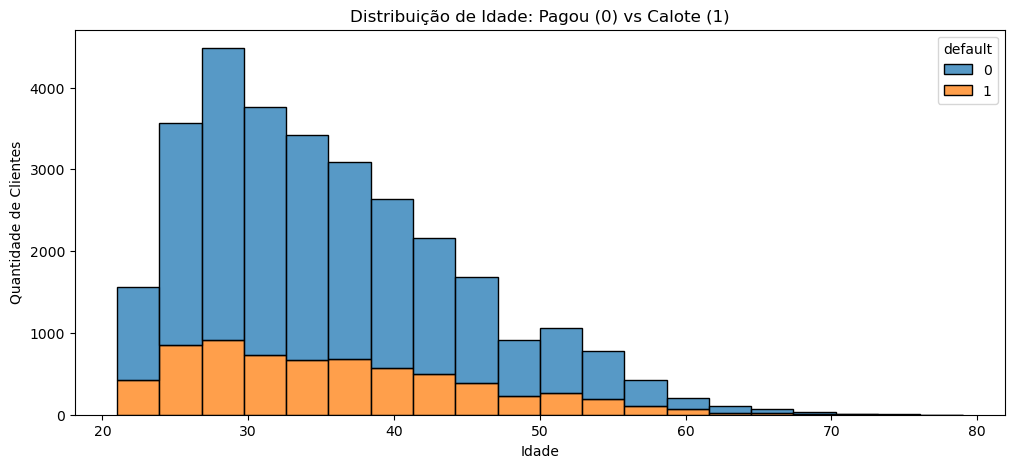

In [15]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='AGE', hue='default', multiple='stack', bins=20)
plt.title('Distribuição de Idade: Pagou (0) vs Calote (1)')
plt.xlabel('Idade')
plt.ylabel('Quantidade de Clientes')
plt.show()

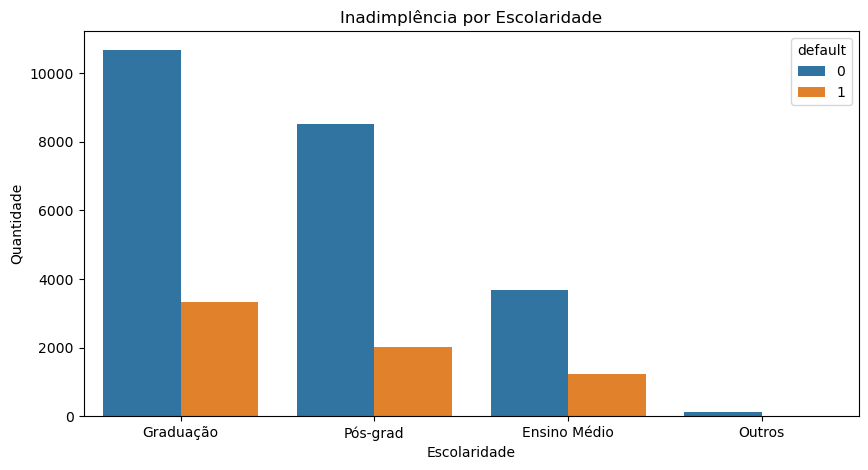

In [16]:
plt.figure(figsize=(10, 5))
education_labels = {1: 'Pós-grad', 2: 'Graduação', 3: 'Ensino Médio', 4: 'Outros'}
df['EDUCATION_LABEL'] = df['EDUCATION'].map(education_labels)
sns.countplot(data=df.dropna(subset=['EDUCATION_LABEL']), x='EDUCATION_LABEL', hue='default')
plt.title('Inadimplência por Escolaridade')
plt.xlabel('Escolaridade')
plt.ylabel('Quantidade')
plt.show()

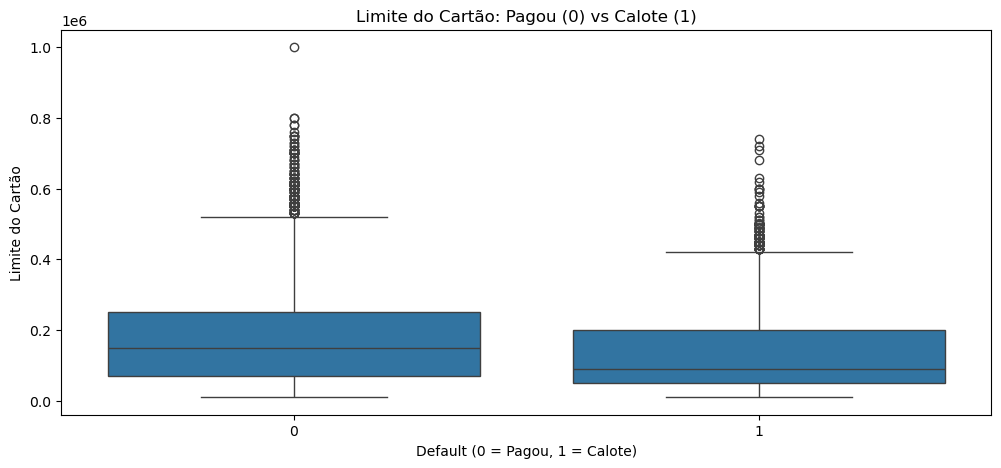

In [17]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='default', y='LIMIT_BAL')
plt.title('Limite do Cartão: Pagou (0) vs Calote (1)')
plt.xlabel('Default (0 = Pagou, 1 = Calote)')
plt.ylabel('Limite do Cartão')
plt.show()

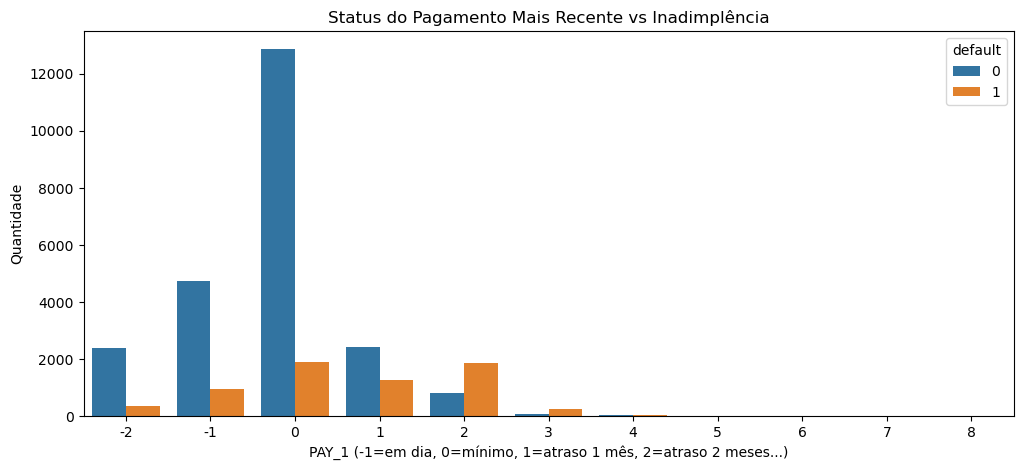

In [18]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='PAY_1', hue='default')
plt.title('Status do Pagamento Mais Recente vs Inadimplência')
plt.xlabel('PAY_1 (-1=em dia, 0=mínimo, 1=atraso 1 mês, 2=atraso 2 meses...)')
plt.ylabel('Quantidade')
plt.show()

## 4. Criação de Indicadores de Risco

In [19]:
df['flag_atraso_grave'] = (df['PAY_1'] >= 2).astype(int)

In [20]:
df['LIMIT_BAL'].median()

140000.0

In [21]:
df['uso_limite'] = df['BILL_AMT1'] / df['LIMIT_BAL']
df['flag_uso_alto'] = (df['uso_limite'] >= 0.8).astype(int)

In [22]:
df['flag_pagou_pouco'] = (df['PAY_AMT1'] < df['BILL_AMT1'] * 0.1).astype(int)

In [23]:
df['qtd_atrasos'] = ((df[['PAY_1','PAY_2','PAY_3']] >= 1).sum(axis=1))
df['flag_multiplos_atrasos'] = (df['qtd_atrasos'] >= 2).astype(int)

In [24]:
df['risk_score'] = (df['flag_atraso_grave'] + 
                    df['flag_uso_alto'] + 
                    df['flag_pagou_pouco'] + 
                    df['flag_multiplos_atrasos'])

In [25]:
df.groupby('default')['risk_score'].mean()

default
0    0.915235
1    1.633183
Name: risk_score, dtype: float64

In [26]:
df['flag_limite_baixo'] = (df['LIMIT_BAL'] < 140000).astype(int)

In [27]:
df['risk_score'] = (df['flag_atraso_grave'] + 
                    df['flag_uso_alto'] + 
                    df['flag_pagou_pouco'] + 
                    df['flag_multiplos_atrasos'] + 
                    df['flag_limite_baixo'])

## 5. Resultados e Interpretação de Negócio

In [28]:
df.groupby('default')['risk_score'].mean()

default
0    1.360103
1    2.259276
Name: risk_score, dtype: float64

In [29]:
inadimplentes = df[df['default'] == 1]
print(f"Total de inadimplentes: {len(inadimplentes)}")
print(f"Inadimplentes com risk_score >= 3: {len(inadimplentes[inadimplentes['risk_score'] >= 3])}")
print(f"Inadimplentes com risk_score >= 4: {len(inadimplentes[inadimplentes['risk_score'] >= 4])}")

Total de inadimplentes: 6630
Inadimplentes com risk_score >= 3: 3127
Inadimplentes com risk_score >= 4: 1522


In [30]:
bons = df[df['default'] == 0]
print(f"Total de bons pagadores: {len(bons)}")
print(f"Bons com risk_score >= 3 (alarmes falsos): {len(bons[bons['risk_score'] >= 3])}")

Total de bons pagadores: 23335
Bons com risk_score >= 3 (alarmes falsos): 4667


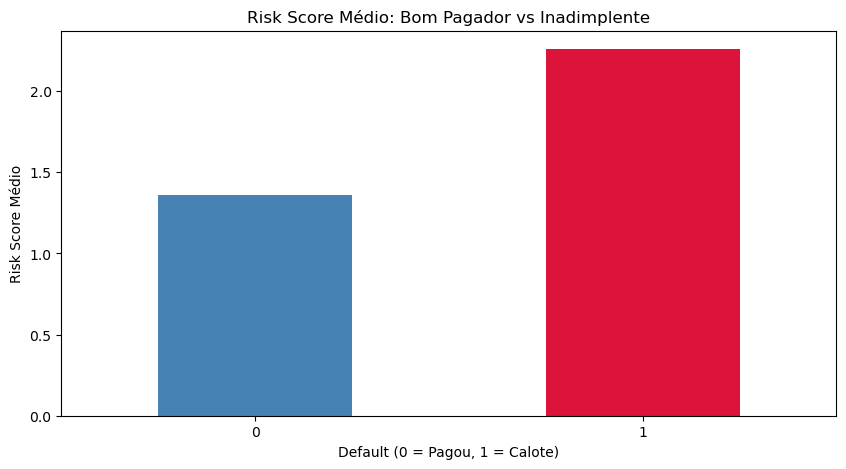

In [31]:
plt.figure(figsize=(10, 5))
df.groupby('default')['risk_score'].mean().plot(kind='bar', color=['steelblue', 'crimson'])
plt.title('Risk Score Médio: Bom Pagador vs Inadimplente')
plt.xlabel('Default (0 = Pagou, 1 = Calote)')
plt.ylabel('Risk Score Médio')
plt.xticks(rotation=0)
plt.show()

    ## 6. Conclusões

- O dataset contém 29.965 clientes, dos quais 6.630 (22%) são inadimplentes
- O histórico de pagamento recente (PAY_1) é o indicador mais forte de inadimplência
- Clientes com 2+ meses de atraso têm probabilidade de calote superior a 50%
- Clientes com limite mais baixo tendem mais a dar calote
- O sistema de risk score (0-5) detecta 47% dos inadimplentes com score >= 3
- A taxa de alarme falso (20%) indica que regras simples capturam parte do problema, mas modelos de machine learning seriam o próximo passo para melhorar a precisão
- Escolaridade e idade influenciam, mas com peso menor que histórico de pagamento